# Imports


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, GRU, GlobalMaxPooling1D, GlobalAveragePooling1D, Concatenate, Layer, Input, Embedding, LSTM, Bidirectional, SpatialDropout1D, BatchNormalization, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.metrics import binary_crossentropy
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, f1_score, fbeta_score, precision_score, recall_score
import gc
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
# path_to_data = '../pre-processing/'

# def load_data(file_name, columns=None):
#     if columns is None:
#         return pd.read_csv(path_to_data + file_name)
#     return pd.read_csv(path_to_data + file_name, usecols=columns)

# AMZN


## Prepare dataset


In [2]:
dataset = pd.read_csv('../pre-processing/amzn_final.csv', usecols=['body_clean', 'entities'], engine='python', on_bad_lines='skip')
print(dataset.head())

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Check if the dataset is empty after filtering
if dataset.empty:
    raise ValueError("The dataset is empty after filtering out neutral entities (entities == 0). Please check your '/content/FinalDataSet.csv' file to ensure it contains relevant data.")
x = dataset['body_clean'].values.astype(str)

y_all = (dataset['entities'].values == 1)

X_train, X_val, Y_train, Y_val = train_test_split(
    x,
    y_all,
    test_size=0.2,
    random_state=2,
    stratify=y_all
)

# Tokenize text to integers
tokenizer = Tokenizer(num_words=50000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# choose length for padding based on 95th percentile
train_lens = [len(s) for s in tokenizer.texts_to_sequences(X_train)]
maxlen = int(np.percentile(train_lens, 80))

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=maxlen, padding='post', truncating='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=maxlen, padding='post', truncating='post')

# Keep integer labels for class-weight calculation
y_train_int = Y_train.copy()
y_val_int   = Y_val.copy()

# Convert labels to one-hot encoding
#Y_train = to_categorical(y_train_int, num_classes=2)
#Y_val   = to_categorical(y_val_int,   num_classes=2)

# Compute balanced class weights and then bias training a bit more toward bearish examples
#classes = np.unique(y_train_int)
#class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_int)
#class_weight = {int(c): float(w) for c, w in zip(classes, class_weights)}

   entities                                         body_clean
0        -1      $amzn waiting bought back short higher price.
1        -1  $spy $fb $amzn $googl $aapl sorry bulls time s...
2        -1  $fb $googl $amzn one-day event. doj anti-trust...
3        -1  $spy $fb $amzn $googl $aapl looking go short j...
4        -1  $amzn timed people (2days tech earnings.. dont...


## Embedder for pre-trained embeddings


In [3]:
glove_path = 'embeddings/glove.twitter.27B.100d.txt'
vocab_size = 50000
embedding_dim = 100

embeddings_index = {}
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        embeddings_index[word] = np.asarray(values[1:], dtype='float32')
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in word_index.items():
    if i < vocab_size:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

## GPU configuration and building LSTM layers


In [4]:
cuda112_bin = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\bin"
cuda112_nvvp = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\libnvvp"
os.environ["PATH"] = f"{cuda112_bin};{cuda112_nvvp};" + os.environ.get("PATH", "")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print('GPUs:', tf.config.list_physical_devices('GPU'))
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

inputs = Input(shape=(maxlen,))
x = Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=False, input_length=maxlen)(inputs)
x = SpatialDropout1D(0.4)(x) # Increased dropout

# Keep LSTM CuDNN-compatible for faster GPU training.
x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
x = Bidirectional(LSTM(96, return_sequences=True))(x) # Reduced LSTM units
x = Dropout(0.3)(x) # Increased dropout

class AttnPool(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform', trainable=True)
    def call(self, x, mask=None):
        a = tf.nn.tanh(tf.matmul(x, self.W))# (B, T, 1)
        a = tf.nn.softmax(a, axis=1)
        return tf.reduce_sum(x * a, axis=1) # (B, H)

x = AttnPool()(x)

x = BatchNormalization()(x)
x = Dense(96, activation='relu', kernel_regularizer=regularizers.l2(1e-3))(x) # Reduced Dense units, increased L2 regularization
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 13)]              0         
                                                                 
 embedding (Embedding)       (None, 13, 100)           5000000   
                                                                 
 spatial_dropout1d (SpatialD  (None, 13, 100)          0         
 ropout1D)                                                       
                                                                 
 conv1d (Conv1D)             (None, 13, 64)            19264     
                                                                 
 bidirectional (Bidirectiona  (None, 13, 192)          123648    
 l)                                                              
                                                      

## Set up callbacks and model


In [5]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc_pr',
        mode='max',
        patience=3,
        restore_best_weights=True,
        verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc_pr',
        mode='max',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        'best_lstm_amzn.keras',
        monitor='val_auc_pr',
        mode='max',
        save_best_only=True),
    tf.keras.callbacks.TerminateOnNaN(),
]

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)
#loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03)


model.compile(
    optimizer=optimizer,
    loss=binary_crossentropy,
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.AUC(curve='PR', name='auc_pr'),
        tf.keras.metrics.Recall(name='recall', class_id=0, thresholds=0.5),
        tf.keras.metrics.Precision(name='precision', class_id=0, thresholds=0.5),
    ]
)

history = model.fit(
    X_train,
    y_train_int.astype('float32'),
    epochs=25,
    batch_size=128,
    validation_data=(X_val, y_val_int.astype('float32')),
    callbacks=callbacks,
)

results = model.evaluate(X_val, y_val_int.astype('float32'), verbose=0, return_dict=True)
print(
    f"Val loss: {results['loss']:.4f} | AUC: {results['auc']:.4f} "
    f"| Recall: {results['recall']:.4f} | Precision: {results['precision']:.4f}"
)

Epoch 1/25
2110/2110 [==============================] - 23s 9ms/step - loss: 0.5416 - auc: 0.8447 - auc_pr: 0.8088 - recall: 0.8796 - precision: 0.7412 - val_loss: 0.4381 - val_auc: 0.8902 - val_auc_pr: 0.8654 - val_recall: 0.9528 - val_precision: 0.7611 - lr: 3.0000e-04
Epoch 2/25
2110/2110 [==============================] - 17s 8ms/step - loss: 0.4349 - auc: 0.8793 - auc_pr: 0.8519 - recall: 0.9221 - precision: 0.7636 - val_loss: 0.3788 - val_auc: 0.9062 - val_auc_pr: 0.8868 - val_recall: 0.9449 - val_precision: 0.7850 - lr: 3.0000e-04
Epoch 3/25
2110/2110 [==============================] - 17s 8ms/step - loss: 0.3954 - auc: 0.8916 - auc_pr: 0.8678 - recall: 0.9264 - precision: 0.7746 - val_loss: 0.3580 - val_auc: 0.9133 - val_auc_pr: 0.8974 - val_recall: 0.9682 - val_precision: 0.7746 - lr: 3.0000e-04
Epoch 4/25
2110/2110 [==============================] - 18s 8ms/step - loss: 0.3791 - auc: 0.8975 - auc_pr: 0.8754 - recall: 0.9271 - precision: 0.7816 - val_loss: 0.3464 - val_auc: 0.

## Calibrated metrics (second-stage threshold tuning)


In [6]:
p_bull = model.predict(X_val, verbose=0).ravel()
y_true = y_val_int
threshold = 0.5
y_pred = (p_bull >= threshold).astype(int)
acc = accuracy_score(y_true, y_pred)

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0)

print(f"Threshold:       {threshold:.2f}")
print(f"Accuracy:        {acc:.4f}")
print(f"Precision macro: {p_macro:.4f} | weighted: {p_weighted:.4f}")
print(f"Recall macro:    {r_macro:.4f} | weighted: {r_weighted:.4f}")
print(f"F1 macro:        {f1_macro:.4f} | weighted: {f1_weighted:.4f}\n")
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

Threshold:       0.50
Accuracy:        0.8663
Precision macro: 0.8720 | weighted: 0.8709
Recall macro:    0.8646 | weighted: 0.8663
F1 macro:        0.8653 | weighted: 0.8657

[[26319  6458]
 [ 2562 32150]]
              precision    recall  f1-score   support

       False     0.9113    0.8030    0.8537     32777
        True     0.8327    0.9262    0.8770     34712

    accuracy                         0.8663     67489
   macro avg     0.8720    0.8646    0.8653     67489
weighted avg     0.8709    0.8663    0.8657     67489



## Loss curve


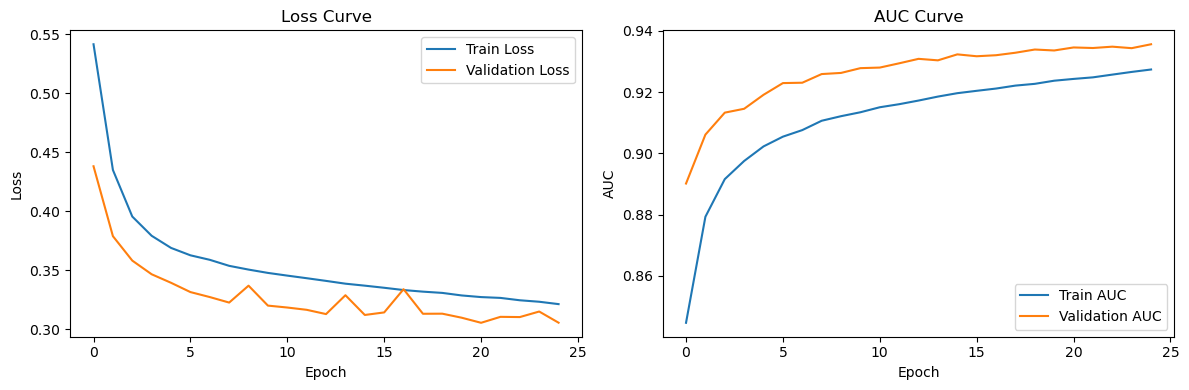

In [7]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('AUC Curve')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
gc.collect()
tf.keras.backend.clear_session()

# AAPL


## Prepare dataset


In [9]:
dataset = pd.read_csv('../pre-processing/aapl_final.csv', usecols=['body_clean', 'entities'], engine='python', on_bad_lines='skip')
print(dataset.head())

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Check if the dataset is empty after filtering
if dataset.empty:
    raise ValueError("The dataset is empty after filtering out neutral entities (entities == 0). Please check your '/content/FinalDataSet.csv' file to ensure it contains relevant data.")
x = dataset['body_clean'].values.astype(str)

y_all = (dataset['entities'].values == 1)

X_train, X_val, Y_train, Y_val = train_test_split(
    x,
    y_all,
    test_size=0.2,
    random_state=2,
    stratify=y_all
)

# Tokenize text to integers
tokenizer = Tokenizer(num_words=50000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# choose length for padding based on 95th percentile
train_lens = [len(s) for s in tokenizer.texts_to_sequences(X_train)]
maxlen = int(np.percentile(train_lens, 80))

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=maxlen, padding='post', truncating='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=maxlen, padding='post', truncating='post')

# Keep integer labels for class-weight calculation
y_train_int = Y_train.copy()
y_val_int   = Y_val.copy()

# Convert labels to one-hot encoding
#Y_train = to_categorical(y_train_int, num_classes=2)
#Y_val   = to_categorical(y_val_int,   num_classes=2)

# Compute balanced class weights and then bias training a bit more toward bearish examples
#classes = np.unique(y_train_int)
#class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_int)
#class_weight = {int(c): float(w) for c, w in zip(classes, class_weights)}

   entities                                         body_clean
0        -1                           $aapl couldn’t break ath
1        -1                   $aapl big profit taking next day
2        -1  $aapl can’t wait see permabulls take aapl $10b...
3        -1  $aapl propped 500 billion injected market........
4        -1    $aapl happy economy crash 2020 ....hate realist


## Embedder for pre-trained embeddings


In [10]:
glove_path = 'embeddings/glove.twitter.27B.100d.txt'
vocab_size = 50000
embedding_dim = 100

embeddings_index = {}
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        embeddings_index[word] = np.asarray(values[1:], dtype='float32')
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in word_index.items():
    if i < vocab_size:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

## GPU configuration and building LSTM layers


In [11]:
cuda112_bin = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\bin"
cuda112_nvvp = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\libnvvp"
os.environ["PATH"] = f"{cuda112_bin};{cuda112_nvvp};" + os.environ.get("PATH", "")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print('GPUs:', tf.config.list_physical_devices('GPU'))
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

inputs = Input(shape=(maxlen,))
x = Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=False, input_length=maxlen)(inputs)
x = SpatialDropout1D(0.4)(x) # Increased dropout

# Keep LSTM CuDNN-compatible for faster GPU training.
x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
x = Bidirectional(LSTM(96, return_sequences=True))(x) # Reduced LSTM units
x = Dropout(0.3)(x) # Increased dropout

class AttnPool(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform', trainable=True)
    def call(self, x, mask=None):
        a = tf.nn.tanh(tf.matmul(x, self.W))# (B, T, 1)
        a = tf.nn.softmax(a, axis=1)
        return tf.reduce_sum(x * a, axis=1) # (B, H)

x = AttnPool()(x)

x = BatchNormalization()(x)
x = Dense(96, activation='relu', kernel_regularizer=regularizers.l2(1e-3))(x) # Reduced Dense units, increased L2 regularization
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 12)]              0         
                                                                 
 embedding (Embedding)       (None, 12, 100)           5000000   
                                                                 
 spatial_dropout1d (SpatialD  (None, 12, 100)          0         
 ropout1D)                                                       
                                                                 
 conv1d (Conv1D)             (None, 12, 64)            19264     
                                                                 
 bidirectional (Bidirectiona  (None, 12, 192)          123648    
 l)                                                              
                                                      

## Set up callbacks and model


In [12]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc_pr',
        mode='max',
        patience=3,
        restore_best_weights=True,
        verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc_pr',
        mode='max',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        'best_lstm_amzn.keras',
        monitor='val_auc_pr',
        mode='max',
        save_best_only=True),
    tf.keras.callbacks.TerminateOnNaN(),
]

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)
#loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03)


model.compile(
    optimizer=optimizer,
    loss=binary_crossentropy,
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.AUC(curve='PR', name='auc_pr'),
        tf.keras.metrics.Recall(name='recall', class_id=0, thresholds=0.5),
        tf.keras.metrics.Precision(name='precision', class_id=0, thresholds=0.5),
    ]
)

history = model.fit(
    X_train,
    y_train_int.astype('float32'),
    epochs=25,
    batch_size=128,
    validation_data=(X_val, y_val_int.astype('float32')),
    callbacks=callbacks,
)

results = model.evaluate(X_val, y_val_int.astype('float32'), verbose=0, return_dict=True)
print(
    f"Val loss: {results['loss']:.4f} | AUC: {results['auc']:.4f} "
    f"| Recall: {results['recall']:.4f} | Precision: {results['precision']:.4f}"
)

Epoch 1/25
3822/3822 [==============================] - 33s 8ms/step - loss: 0.4939 - auc: 0.8521 - auc_pr: 0.8066 - recall: 0.9203 - precision: 0.7385 - val_loss: 0.3839 - val_auc: 0.9003 - val_auc_pr: 0.8745 - val_recall: 0.9741 - val_precision: 0.7572 - lr: 3.0000e-04
Epoch 2/25
3822/3822 [==============================] - 31s 8ms/step - loss: 0.3929 - auc: 0.8864 - auc_pr: 0.8531 - recall: 0.9362 - precision: 0.7673 - val_loss: 0.3481 - val_auc: 0.9103 - val_auc_pr: 0.8870 - val_recall: 0.9312 - val_precision: 0.7966 - lr: 3.0000e-04
Epoch 3/25
3822/3822 [==============================] - 31s 8ms/step - loss: 0.3715 - auc: 0.8960 - auc_pr: 0.8667 - recall: 0.9348 - precision: 0.7788 - val_loss: 0.3499 - val_auc: 0.9149 - val_auc_pr: 0.8931 - val_recall: 0.8810 - val_precision: 0.8239 - lr: 3.0000e-04
Epoch 4/25
3822/3822 [==============================] - 31s 8ms/step - loss: 0.3621 - auc: 0.9013 - auc_pr: 0.8739 - recall: 0.9364 - precision: 0.7838 - val_loss: 0.3307 - val_auc: 0.

## Calibrated metrics (second-stage threshold tuning)


In [13]:
p_bull = model.predict(X_val, verbose=0).ravel()
y_true = y_val_int
threshold = 0.5
y_pred = (p_bull >= threshold).astype(int)
acc = accuracy_score(y_true, y_pred)

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0)

print(f"Threshold:       {threshold:.2f}")
print(f"Accuracy:        {acc:.4f}")
print(f"Precision macro: {p_macro:.4f} | weighted: {p_weighted:.4f}")
print(f"Recall macro:    {r_macro:.4f} | weighted: {r_weighted:.4f}")
print(f"F1 macro:        {f1_macro:.4f} | weighted: {f1_weighted:.4f}\n")
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

Threshold:       0.50
Accuracy:        0.8661
Precision macro: 0.8750 | weighted: 0.8740
Recall macro:    0.8648 | weighted: 0.8661
F1 macro:        0.8650 | weighted: 0.8652

[[47337 12714]
 [ 3656 58588]]
              precision    recall  f1-score   support

       False     0.9283    0.7883    0.8526     60051
        True     0.8217    0.9413    0.8774     62244

    accuracy                         0.8661    122295
   macro avg     0.8750    0.8648    0.8650    122295
weighted avg     0.8740    0.8661    0.8652    122295



## Loss curve


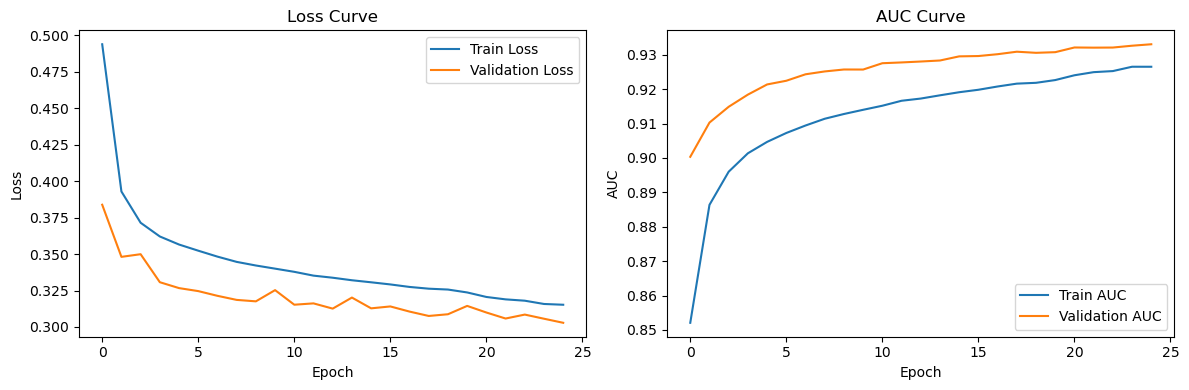

In [14]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('AUC Curve')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
gc.collect()
tf.keras.backend.clear_session()

# FB


## Prepare dataset


In [4]:
dataset = pd.read_csv('../pre-processing/fb_final.csv', usecols=['body_clean', 'entities'], engine='python', on_bad_lines='skip')
print(dataset.head())

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Check if the dataset is empty after filtering
if dataset.empty:
    raise ValueError("The dataset is empty after filtering out neutral entities (entities == 0). Please check your '/content/FinalDataSet.csv' file to ensure it contains relevant data.")
x = dataset['body_clean'].values.astype(str)

y_all = (dataset['entities'].values == 1)

X_train, X_val, Y_train, Y_val = train_test_split(
    x,
    y_all,
    test_size=0.2,
    random_state=2,
    stratify=y_all
)

# Tokenize text to integers
tokenizer = Tokenizer(num_words=50000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# choose length for padding based on 95th percentile
train_lens = [len(s) for s in tokenizer.texts_to_sequences(X_train)]
maxlen = int(np.percentile(train_lens, 80))

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=maxlen, padding='post', truncating='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=maxlen, padding='post', truncating='post')

# Keep integer labels for class-weight calculation
y_train_int = Y_train.copy()
y_val_int   = Y_val.copy()

# Convert labels to one-hot encoding
#Y_train = to_categorical(y_train_int, num_classes=2)
#Y_val   = to_categorical(y_val_int,   num_classes=2)

# Compute balanced class weights and then bias training a bit more toward bearish examples
#classes = np.unique(y_train_int)
#class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_int)
#class_weight = {int(c): float(w) for c, w in zip(classes, class_weights)}

   entities                                         body_clean
0        -1        $fb life support. expect massive drop soon.
1        -1  $fb shorting trash meta dead. competition disa...
2        -1                          one buying garbage lmaooo
3        -1   total loss. shorted $fb, can't believe it’s bad.
4        -1                                one company. crash.


## Embedder for pre-trained embeddings


In [5]:
glove_path = 'embeddings/glove.twitter.27B.100d.txt'
vocab_size = 50000
embedding_dim = 100

embeddings_index = {}
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        embeddings_index[word] = np.asarray(values[1:], dtype='float32')
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in word_index.items():
    if i < vocab_size:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

## GPU configuration and building LSTM layers


In [6]:
cuda112_bin = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\bin"
cuda112_nvvp = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\libnvvp"
os.environ["PATH"] = f"{cuda112_bin};{cuda112_nvvp};" + os.environ.get("PATH", "")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print('GPUs:', tf.config.list_physical_devices('GPU'))
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

inputs = Input(shape=(maxlen,))
x = Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=False, input_length=maxlen)(inputs)
x = SpatialDropout1D(0.4)(x) # Increased dropout

# Keep LSTM CuDNN-compatible for faster GPU training.
x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
x = Bidirectional(LSTM(96, return_sequences=True))(x) # Reduced LSTM units
x = Dropout(0.3)(x) # Increased dropout

class AttnPool(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform', trainable=True)
    def call(self, x, mask=None):
        a = tf.nn.tanh(tf.matmul(x, self.W))# (B, T, 1)
        a = tf.nn.softmax(a, axis=1)
        return tf.reduce_sum(x * a, axis=1) # (B, H)

x = AttnPool()(x)

x = BatchNormalization()(x)
x = Dense(96, activation='relu', kernel_regularizer=regularizers.l2(1e-3))(x) # Reduced Dense units, increased L2 regularization
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 12)]              0         
                                                                 
 embedding (Embedding)       (None, 12, 100)           5000000   
                                                                 
 spatial_dropout1d (SpatialD  (None, 12, 100)          0         
 ropout1D)                                                       
                                                                 
 conv1d (Conv1D)             (None, 12, 64)            19264     
                                                                 
 bidirectional (Bidirectiona  (None, 12, 192)          123648    
 l)                                                              
                                                      

## Set up callbacks and model


In [7]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc_pr',
        mode='max',
        patience=3,
        restore_best_weights=True,
        verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc_pr',
        mode='max',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        'best_lstm_amzn.keras',
        monitor='val_auc_pr',
        mode='max',
        save_best_only=True),
    tf.keras.callbacks.TerminateOnNaN(),
]

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)
#loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03)


model.compile(
    optimizer=optimizer,
    loss=binary_crossentropy,
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.AUC(curve='PR', name='auc_pr'),
        tf.keras.metrics.Recall(name='recall', class_id=0, thresholds=0.5),
        tf.keras.metrics.Precision(name='precision', class_id=0, thresholds=0.5),
    ]
)

history = model.fit(
    X_train,
    y_train_int.astype('float32'),
    epochs=25,
    batch_size=128,
    validation_data=(X_val, y_val_int.astype('float32')),
    callbacks=callbacks,
)

results = model.evaluate(X_val, y_val_int.astype('float32'), verbose=0, return_dict=True)
print(
    f"Val loss: {results['loss']:.4f} | AUC: {results['auc']:.4f} "
    f"| Recall: {results['recall']:.4f} | Precision: {results['precision']:.4f}"
)

Epoch 1/25
1293/1293 [==============================] - 16s 9ms/step - loss: 0.5182 - auc: 0.8690 - auc_pr: 0.8238 - recall: 0.8956 - precision: 0.7660 - val_loss: 0.4116 - val_auc: 0.9116 - val_auc_pr: 0.8811 - val_recall: 0.9418 - val_precision: 0.8025 - lr: 3.0000e-04
Epoch 2/25
1293/1293 [==============================] - 12s 9ms/step - loss: 0.4106 - auc: 0.8989 - auc_pr: 0.8624 - recall: 0.9501 - precision: 0.7857 - val_loss: 0.3487 - val_auc: 0.9243 - val_auc_pr: 0.9000 - val_recall: 0.9729 - val_precision: 0.7985 - lr: 3.0000e-04
Epoch 3/25
1293/1293 [==============================] - 11s 9ms/step - loss: 0.3682 - auc: 0.9087 - auc_pr: 0.8771 - recall: 0.9545 - precision: 0.7937 - val_loss: 0.3234 - val_auc: 0.9297 - val_auc_pr: 0.9084 - val_recall: 0.9649 - val_precision: 0.8091 - lr: 3.0000e-04
Epoch 4/25
1293/1293 [==============================] - 11s 9ms/step - loss: 0.3438 - auc: 0.9158 - auc_pr: 0.8881 - recall: 0.9533 - precision: 0.7991 - val_loss: 0.3043 - val_auc: 0.

## Calibrated metrics (second-stage threshold tuning)


In [8]:
p_bull = model.predict(X_val, verbose=0).ravel()
y_true = y_val_int
threshold = 0.5
y_pred = (p_bull >= threshold).astype(int)
acc = accuracy_score(y_true, y_pred)

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0)

print(f"Threshold:       {threshold:.2f}")
print(f"Accuracy:        {acc:.4f}")
print(f"Precision macro: {p_macro:.4f} | weighted: {p_weighted:.4f}")
print(f"Recall macro:    {r_macro:.4f} | weighted: {r_weighted:.4f}")
print(f"F1 macro:        {f1_macro:.4f} | weighted: {f1_weighted:.4f}\n")
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

Threshold:       0.50
Accuracy:        0.8863
Precision macro: 0.8905 | weighted: 0.8901
Recall macro:    0.8857 | weighted: 0.8863
F1 macro:        0.8858 | weighted: 0.8859

[[17059  3394]
 [ 1310 19601]]
              precision    recall  f1-score   support

       False     0.9287    0.8341    0.8788     20453
        True     0.8524    0.9374    0.8929     20911

    accuracy                         0.8863     41364
   macro avg     0.8905    0.8857    0.8858     41364
weighted avg     0.8901    0.8863    0.8859     41364



## Loss curve


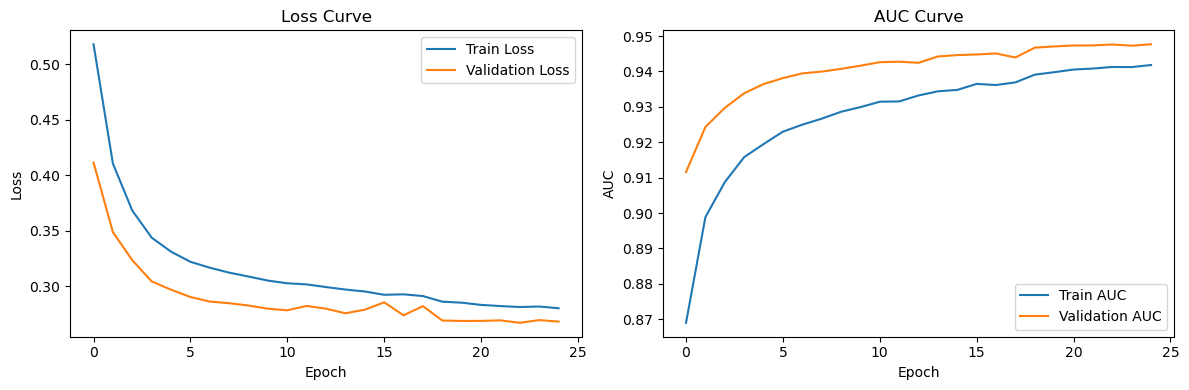

In [9]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('AUC Curve')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
gc.collect()
tf.keras.backend.clear_session()

# NVDA


## Prepare dataset


In [23]:
dataset = pd.read_csv('../pre-processing/nvda_final.csv', usecols=['body_clean', 'entities'], engine='python', on_bad_lines='skip')
print(dataset.head())

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Check if the dataset is empty after filtering
if dataset.empty:
    raise ValueError("The dataset is empty after filtering out neutral entities (entities == 0). Please check your '/content/FinalDataSet.csv' file to ensure it contains relevant data.")
x = dataset['body_clean'].values.astype(str)

y_all = (dataset['entities'].values == 1)

X_train, X_val, Y_train, Y_val = train_test_split(
    x,
    y_all,
    test_size=0.2,
    random_state=2,
    stratify=y_all
)

# Tokenize text to integers
tokenizer = Tokenizer(num_words=50000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# choose length for padding based on 95th percentile
train_lens = [len(s) for s in tokenizer.texts_to_sequences(X_train)]
maxlen = int(np.percentile(train_lens, 80))

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=maxlen, padding='post', truncating='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=maxlen, padding='post', truncating='post')

# Keep integer labels for class-weight calculation
y_train_int = Y_train.copy()
y_val_int   = Y_val.copy()

# Convert labels to one-hot encoding
#Y_train = to_categorical(y_train_int, num_classes=2)
#Y_val   = to_categorical(y_val_int,   num_classes=2)

# Compute balanced class weights and then bias training a bit more toward bearish examples
#classes = np.unique(y_train_int)
#class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_int)
#class_weight = {int(c): float(w) for c, w in zip(classes, class_weights)}

   entities                                         body_clean
0        -1  $nvda bad news priced in? lol who’s believing ...
1        -1  going dump hard. $nvda, $aapl, $msft: garbage ...
2        -1             $nvda gone zero hero, going back zero.
3        -1         $nvda going down. disaster waiting happen.
4        -1  nasdaq 150 points today. another 200-250 tomor...


## Embedder for pre-trained embeddings


In [24]:
glove_path = 'embeddings/glove.twitter.27B.100d.txt'
vocab_size = 50000
embedding_dim = 100

embeddings_index = {}
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        embeddings_index[word] = np.asarray(values[1:], dtype='float32')
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in word_index.items():
    if i < vocab_size:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

## GPU configuration and building LSTM layers


In [25]:
cuda112_bin = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\bin"
cuda112_nvvp = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\libnvvp"
os.environ["PATH"] = f"{cuda112_bin};{cuda112_nvvp};" + os.environ.get("PATH", "")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print('GPUs:', tf.config.list_physical_devices('GPU'))
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

inputs = Input(shape=(maxlen,))
x = Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=False, input_length=maxlen)(inputs)
x = SpatialDropout1D(0.4)(x) # Increased dropout

# Keep LSTM CuDNN-compatible for faster GPU training.
x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
x = Bidirectional(LSTM(96, return_sequences=True))(x) # Reduced LSTM units
x = Dropout(0.3)(x) # Increased dropout

class AttnPool(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform', trainable=True)
    def call(self, x, mask=None):
        a = tf.nn.tanh(tf.matmul(x, self.W))# (B, T, 1)
        a = tf.nn.softmax(a, axis=1)
        return tf.reduce_sum(x * a, axis=1) # (B, H)

x = AttnPool()(x)

x = BatchNormalization()(x)
x = Dense(96, activation='relu', kernel_regularizer=regularizers.l2(1e-3))(x) # Reduced Dense units, increased L2 regularization
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 11)]              0         
                                                                 
 embedding (Embedding)       (None, 11, 100)           5000000   
                                                                 
 spatial_dropout1d (SpatialD  (None, 11, 100)          0         
 ropout1D)                                                       
                                                                 
 conv1d (Conv1D)             (None, 11, 64)            19264     
                                                                 
 bidirectional (Bidirectiona  (None, 11, 192)          123648    
 l)                                                              
                                                      

## Set up callbacks and model


In [26]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc_pr',
        mode='max',
        patience=3,
        restore_best_weights=True,
        verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc_pr',
        mode='max',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        'best_lstm_amzn.keras',
        monitor='val_auc_pr',
        mode='max',
        save_best_only=True),
    tf.keras.callbacks.TerminateOnNaN(),
]

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)
#loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03)


model.compile(
    optimizer=optimizer,
    loss=binary_crossentropy,
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.AUC(curve='PR', name='auc_pr'),
        tf.keras.metrics.Recall(name='recall', class_id=0, thresholds=0.5),
        tf.keras.metrics.Precision(name='precision', class_id=0, thresholds=0.5),
    ]
)

history = model.fit(
    X_train,
    y_train_int.astype('float32'),
    epochs=25,
    batch_size=128,
    validation_data=(X_val, y_val_int.astype('float32')),
    callbacks=callbacks,
)

results = model.evaluate(X_val, y_val_int.astype('float32'), verbose=0, return_dict=True)
print(
    f"Val loss: {results['loss']:.4f} | AUC: {results['auc']:.4f} "
    f"| Recall: {results['recall']:.4f} | Precision: {results['precision']:.4f}"
)

Epoch 1/25
2144/2144 [==============================] - 20s 9ms/step - loss: 0.4537 - auc: 0.8916 - auc_pr: 0.8484 - recall: 0.9184 - precision: 0.7936 - val_loss: 0.3308 - val_auc: 0.9286 - val_auc_pr: 0.9007 - val_recall: 0.9850 - val_precision: 0.8157 - lr: 3.0000e-04
Epoch 2/25
2144/2144 [==============================] - 18s 8ms/step - loss: 0.3403 - auc: 0.9168 - auc_pr: 0.8827 - recall: 0.9630 - precision: 0.8150 - val_loss: 0.2933 - val_auc: 0.9370 - val_auc_pr: 0.9142 - val_recall: 0.9613 - val_precision: 0.8408 - lr: 3.0000e-04
Epoch 3/25
2144/2144 [==============================] - 18s 8ms/step - loss: 0.3092 - auc: 0.9250 - auc_pr: 0.8957 - recall: 0.9659 - precision: 0.8235 - val_loss: 0.2735 - val_auc: 0.9414 - val_auc_pr: 0.9203 - val_recall: 0.9826 - val_precision: 0.8333 - lr: 3.0000e-04
Epoch 4/25
2144/2144 [==============================] - 18s 8ms/step - loss: 0.2972 - auc: 0.9285 - auc_pr: 0.9004 - recall: 0.9656 - precision: 0.8289 - val_loss: 0.2712 - val_auc: 0.

## Calibrated metrics (second-stage threshold tuning)


In [27]:
p_bull = model.predict(X_val, verbose=0).ravel()
y_true = y_val_int
threshold = 0.5
y_pred = (p_bull >= threshold).astype(int)
acc = accuracy_score(y_true, y_pred)

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0)

print(f"Threshold:       {threshold:.2f}")
print(f"Accuracy:        {acc:.4f}")
print(f"Precision macro: {p_macro:.4f} | weighted: {p_weighted:.4f}")
print(f"Recall macro:    {r_macro:.4f} | weighted: {r_weighted:.4f}")
print(f"F1 macro:        {f1_macro:.4f} | weighted: {f1_weighted:.4f}\n")
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

Threshold:       0.50
Accuracy:        0.9056
Precision macro: 0.9101 | weighted: 0.9095
Recall macro:    0.9049 | weighted: 0.9056
F1 macro:        0.9053 | weighted: 0.9053

[[28871  4934]
 [ 1538 33244]]
              precision    recall  f1-score   support

       False     0.9494    0.8540    0.8992     33805
        True     0.8708    0.9558    0.9113     34782

    accuracy                         0.9056     68587
   macro avg     0.9101    0.9049    0.9053     68587
weighted avg     0.9095    0.9056    0.9053     68587



## Loss curve


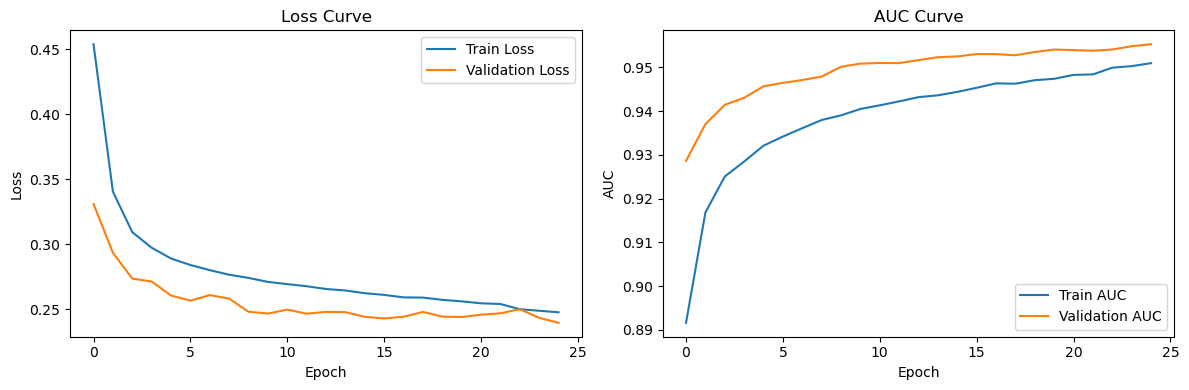

In [28]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('AUC Curve')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

In [29]:
gc.collect()
tf.keras.backend.clear_session()

# TSLA


## Prepare dataset


In [11]:
dataset = pd.read_csv('../pre-processing/tsla_final.csv', usecols=['body_clean', 'entities'], engine='python', on_bad_lines='skip')
print(dataset.head())

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Check if the dataset is empty after filtering
if dataset.empty:
    raise ValueError("The dataset is empty after filtering out neutral entities (entities == 0). Please check your '/content/FinalDataSet.csv' file to ensure it contains relevant data.")
x = dataset['body_clean'].values.astype(str)

y_all = (dataset['entities'].values == 1)

X_train, X_val, Y_train, Y_val = train_test_split(
    x,
    y_all,
    test_size=0.2,
    random_state=2,
    stratify=y_all
)

# Tokenize text to integers
tokenizer = Tokenizer(num_words=50000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# choose length for padding based on 95th percentile
train_lens = [len(s) for s in tokenizer.texts_to_sequences(X_train)]
maxlen = int(np.percentile(train_lens, 80))

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=maxlen, padding='post', truncating='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=maxlen, padding='post', truncating='post')

# Keep integer labels for class-weight calculation
y_train_int = Y_train.copy()
y_val_int   = Y_val.copy()

# Convert labels to one-hot encoding
#Y_train = to_categorical(y_train_int, num_classes=2)
#Y_val   = to_categorical(y_val_int,   num_classes=2)

# Compute balanced class weights and then bias training a bit more toward bearish examples
#classes = np.unique(y_train_int)
#class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_int)
#class_weight = {int(c): float(w) for c, w in zip(classes, class_weights)}

   entities                                         body_clean
0        -1  $tsla painful holding puts xmas hold tight bea...
1        -1                                    $tsla short it.
2        -1  $tsla thursday short attack open like today le...
3        -1  $tsla bulls delirious maybe rightfully so. how...
4        -1                                  $tsla last party.


## Embedder for pre-trained embeddings


In [12]:
glove_path = 'embeddings/glove.twitter.27B.100d.txt'
vocab_size = 50000
embedding_dim = 100

embeddings_index = {}
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        embeddings_index[word] = np.asarray(values[1:], dtype='float32')
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in word_index.items():
    if i < vocab_size:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

## GPU configuration and building LSTM layers


In [ ]:
cuda112_bin = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\bin"
cuda112_nvvp = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\libnvvp"
os.environ["PATH"] = f"{cuda112_bin};{cuda112_nvvp};" + os.environ.get("PATH", "")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print('GPUs:', tf.config.list_physical_devices('GPU'))
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

inputs = Input(shape=(maxlen,))
x = Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=False, input_length=maxlen)(inputs)
x = SpatialDropout1D(0.3)(x) # Increased dropout

# Keep LSTM CuDNN-compatible for faster GPU training.
x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
x = Bidirectional(LSTM(96, return_sequences=True))(x) # Reduced LSTM units
x = Dropout(0.3)(x) # Increased dropout

class AttnPool(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform', trainable=True)
    def call(self, x, mask=None):
        a = tf.nn.tanh(tf.matmul(x, self.W))# (B, T, 1)
        a = tf.nn.softmax(a, axis=1)
        return tf.reduce_sum(x * a, axis=1) # (B, H)

x = AttnPool()(x)

x = BatchNormalization()(x)
x = Dense(96, activation='relu', kernel_regularizer=regularizers.l2(1e-3))(x) # Reduced Dense units, increased L2 regularization
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 13)]              0         
                                                                 
 embedding (Embedding)       (None, 13, 100)           5000000   
                                                                 
 spatial_dropout1d (SpatialD  (None, 13, 100)          0         
 ropout1D)                                                       
                                                                 
 conv1d (Conv1D)             (None, 13, 64)            19264     
                                                                 
 bidirectional (Bidirectiona  (None, 13, 192)          123648    
 l)                                                              
                                                      

## Set up callbacks and model


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc_pr',
        mode='max',
        patience=3,
        restore_best_weights=True,
        verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc_pr',
        mode='max',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        'best_lstm_amzn.keras',
        monitor='val_auc_pr',
        mode='max',
        save_best_only=True),
    tf.keras.callbacks.TerminateOnNaN(),
]

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)
#loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03)


model.compile(
    optimizer=optimizer,
    loss=binary_crossentropy,
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.AUC(curve='PR', name='auc_pr'),
        tf.keras.metrics.Recall(name='recall', class_id=0, thresholds=0.45),
        tf.keras.metrics.Precision(name='precision', class_id=0, thresholds=0.45),
    ]
)

history = model.fit(
    X_train,
    y_train_int.astype('float32'),
    epochs=25,
    batch_size=128,
    validation_data=(X_val, y_val_int.astype('float32')),
    callbacks=callbacks,
)

results = model.evaluate(X_val, y_val_int.astype('float32'), verbose=0, return_dict=True)
print(
    f"Val loss: {results['loss']:.4f} | AUC: {results['auc']:.4f} "
    f"| Recall: {results['recall']:.4f} | Precision: {results['precision']:.4f}"
)

Epoch 1/25
6079/6079 [==============================] - 55s 9ms/step - loss: 0.5698 - auc: 0.7905 - auc_pr: 0.7584 - recall: 0.8282 - precision: 0.6760 - val_loss: 0.4654 - val_auc: 0.8531 - val_auc_pr: 0.8312 - val_recall: 0.9100 - val_precision: 0.7042 - lr: 3.0000e-04
Epoch 2/25
6079/6079 [==============================] - 51s 8ms/step - loss: 0.4828 - auc: 0.8333 - auc_pr: 0.8071 - recall: 0.8522 - precision: 0.7103 - val_loss: 0.4413 - val_auc: 0.8648 - val_auc_pr: 0.8448 - val_recall: 0.8709 - val_precision: 0.7372 - lr: 3.0000e-04
Epoch 3/25
6079/6079 [==============================] - 50s 8ms/step - loss: 0.4686 - auc: 0.8439 - auc_pr: 0.8201 - recall: 0.8541 - precision: 0.7205 - val_loss: 0.4338 - val_auc: 0.8701 - val_auc_pr: 0.8511 - val_recall: 0.8997 - val_precision: 0.7297 - lr: 3.0000e-04
Epoch 4/25
6079/6079 [==============================] - 49s 8ms/step - loss: 0.4609 - auc: 0.8499 - auc_pr: 0.8269 - recall: 0.8587 - precision: 0.7257 - val_loss: 0.4339 - val_auc: 0.

## Calibrated metrics (second-stage threshold tuning)


In [15]:
p_bull = model.predict(X_val, verbose=0).ravel()
y_true = y_val_int
threshold = 0.5
y_pred = (p_bull >= threshold).astype(int)
acc = accuracy_score(y_true, y_pred)

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0)

print(f"Threshold:       {threshold:.2f}")
print(f"Accuracy:        {acc:.4f}")
print(f"Precision macro: {p_macro:.4f} | weighted: {p_weighted:.4f}")
print(f"Recall macro:    {r_macro:.4f} | weighted: {r_weighted:.4f}")
print(f"F1 macro:        {f1_macro:.4f} | weighted: {f1_weighted:.4f}\n")
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

Threshold:       0.50
Accuracy:        0.8083
Precision macro: 0.8180 | weighted: 0.8179
Recall macro:    0.8082 | weighted: 0.8083
F1 macro:        0.8068 | weighted: 0.8068

[[70011 27106]
 [10181 87229]]
              precision    recall  f1-score   support

       False     0.8730    0.7209    0.7897     97117
        True     0.7629    0.8955    0.8239     97410

    accuracy                         0.8083    194527
   macro avg     0.8180    0.8082    0.8068    194527
weighted avg     0.8179    0.8083    0.8068    194527



## Loss curve


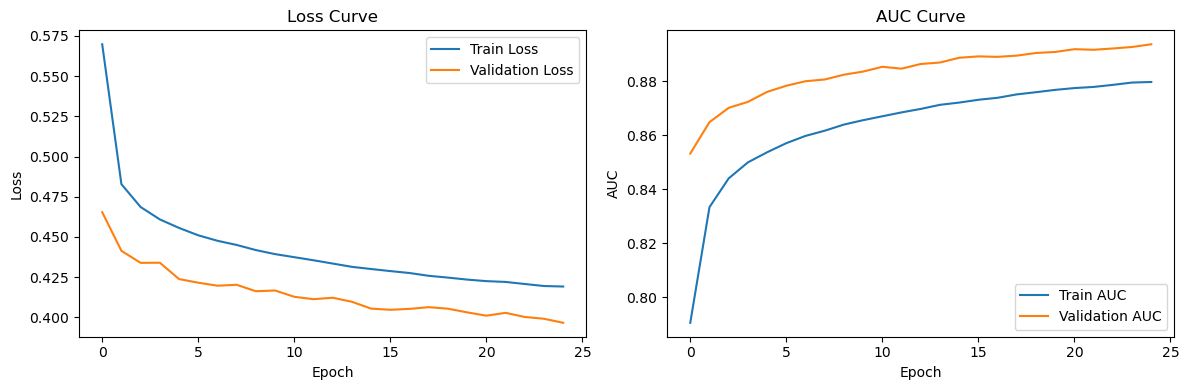

In [16]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('AUC Curve')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
gc.collect()
tf.keras.backend.clear_session()